# 02. 흡연 여부와 건강 지표 간 상관관계 분석

> 이 노트북은 원본 통합 노트북 `소스_코드_8팀_생체_신호_기반_흡연_여부_비교_시각화_프로젝트__-_종합.ipynb` 의 관련 셀들을 주제별로 재구성한 것입니다. 코드는 원본 그대로 옮겨왔으며(실행 결과만 초기화), 새로 작성하거나 수정한 로직은 없습니다.
>
> 실행하려면 `train_dataset.csv`(Kaggle: Smoker Status Prediction Dataset)를 동일 폴더에 두어야 합니다. 데이터 파일은 저장소에 포함되어 있지 않습니다.
>
> 원본에는 서로 다른 시점에 작성된 3개의 전처리 버전이 섞여 있습니다 (자세한 내용은 `docs/03_issues_and_troubleshooting.md` 참고). 이 재구성본은 그 버전들을 **삭제하거나 하나로 합치지 않고**, 각 노트북 안에서 '버전 A/B/C'로 구분해 모두 보존했습니다.

> ### ⚠️ 실행 순서 주의 — 파일 순서대로 돌리면 안 됩니다
>
> 이 노트북들은 원본 통합 노트북을 **주제별로** 재배치한 것이라,
> `01 → 02 → … → 06` 순서로 실행하면 변수 정의 순서가 깨집니다.
>
> 구체적으로 — `01` 의 **버전 B** 절이 `train = pd.read_csv(...)` 로 데이터를 다시 읽어
> **버전 A 에서 만든 `BMI_group` 컬럼을 지웁니다.** 그 상태로 `03` 을 실행하면
> `KeyError: 'BMI_group'` 이 납니다. (실제로 확인했습니다 — 파일 순서 실행 시 에러 47건)
>
> **이 노트북에 담긴 출력은 원본 통합 노트북의 셀 순서대로 실행해 얻은 것입니다.**
> 원본 코드셀 106개 중 105개가 매칭됐고, **실행 에러 0건 · 그래프 81개**가 재현됐습니다.
>
> 직접 재현하려면 `원본/소스_코드_8팀….ipynb` 를 순서대로 실행하거나,
> 각 절을 독립적으로 돌리려면 그 절 앞에서 데이터를 다시 읽고 파생 컬럼을 재생성해야 합니다.
>
> 데이터: `data/train_dataset.csv` (저장소 미포함 — [`data/README.md`](../../data/README.md))


## 버전 A — 피어슨 상관계수 + 가로 막대그래프

In [ ]:
train

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,BMI_group
0,35,170,85,97.0,0.9,0.9,1,1,118,78,97,239,153,70,142,19.8,1,1.0,61,115,125,1,1,29.411765,비만2단계
1,20,175,110,110.0,0.7,0.9,1,1,119,79,88,211,128,71,114,15.9,1,1.1,19,25,30,1,0,35.918367,고도비만
3,45,165,80,94.0,0.8,0.7,1,1,158,88,249,210,366,46,91,16.9,1,0.9,32,36,36,0,0,29.384757,비만2단계
4,20,165,60,81.0,1.5,0.1,1,1,109,64,100,179,200,47,92,14.9,1,1.2,26,28,15,0,0,22.038567,정상
5,60,160,50,78.0,1.0,0.9,2,2,126,75,114,177,74,98,64,13.9,1,1.0,47,23,70,0,1,19.531250,정상
6,40,175,90,95.0,0.9,1.0,1,1,130,88,90,207,331,39,102,16.5,1,1.0,19,22,19,0,0,29.387755,비만2단계
7,40,180,75,85.0,1.5,1.5,1,1,110,60,100,170,62,58,99,14.0,2,1.4,29,20,32,1,1,23.148148,과체중
8,40,170,60,74.0,1.2,1.5,1,1,89,57,83,178,69,60,104,12.9,2,0.7,17,17,14,0,0,20.761246,정상
9,45,155,55,78.0,0.7,1.0,1,1,114,81,96,184,177,41,107,13.1,1,0.6,22,15,56,0,0,22.892820,정상
10,40,160,60,77.6,0.5,0.5,1,1,130,80,94,154,91,63,73,14.3,1,0.5,19,13,9,0,1,23.437500,과체중


In [ ]:
train.isnull().sum()

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
BMI                    0
BMI_group              0
dtype: int64

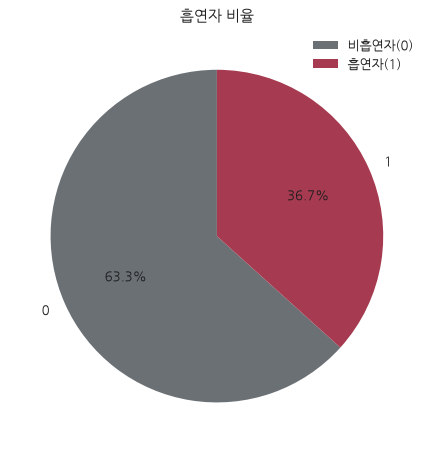

In [ ]:
train['smoking']
ts = train['smoking'].value_counts()
#흡연 비흡연 인원 수
ts.plot(kind="pie",autopct='%1.1f%%', figsize=(6,6), startangle=90,
        colors=[C_NONSMOKER, C_SMOKER])
plt.legend(['비흡연자(0)', '흡연자(1)'], loc="upper right", frameon=False)
plt.title("흡연자 비율")
plt.ylabel("")  # 불필요한 y라벨 제거
plt.show()

In [ ]:
corr = train.corr(numeric_only=True)
corr
corr = train.select_dtypes(include='number').corr()['smoking'].drop('smoking').sort_values(ascending=True)
corr
# 흡연 여부 상관계수 파악하기

HDL                   -0.180899
age                   -0.167949
LDL                   -0.053937
Cholesterol           -0.027135
hearing(left)         -0.022810
hearing(right)        -0.020335
Urine protein          0.014296
systolic               0.070547
AST                    0.082912
eyesight(left)         0.097287
fasting blood sugar    0.098298
relaxation             0.104368
eyesight(right)        0.105975
dental caries          0.107385
BMI                    0.107735
ALT                    0.149201
waist(cm)              0.224976
serum creatinine       0.247212
triglyceride           0.251041
Gtp                    0.268044
weight(kg)             0.301805
height(cm)             0.395455
hemoglobin             0.402488
Name: smoking, dtype: float64

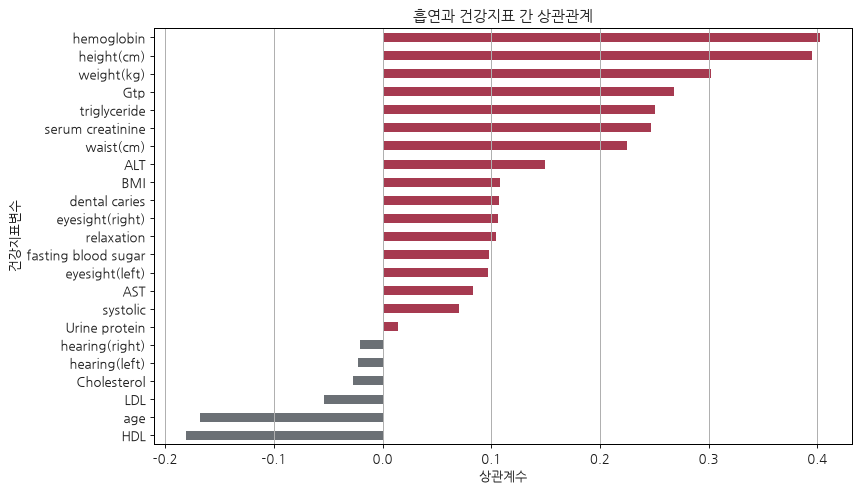

In [ ]:
colors = [C_SMOKER if x >= 0 else C_NONSMOKER for x in corr.values]
corr.plot(kind="barh",color=colors, figsize=(10,6))
plt.title('흡연과 건강지표 간 상관관계', color=C_TEXT)
plt.xlabel('상관계수', color=C_TEXT)
plt.ylabel('건강지표변수', color=C_TEXT)
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

## 버전 B — Point-biserial 상관계수 + p-value (통계적 유의성 포함)

In [ ]:
#흡연과상관관계분석
cont_cols = [
    'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
    'eyesight(left)', 'eyesight(right)',
    'systolic', 'relaxation', 'fasting blood sugar',
    'Cholesterol', 'triglyceride', 'HDL', 'LDL',
    'hemoglobin', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'BMI'
]

corr_rows = []
for col in cont_cols:
    r, p = stats.pointbiserialr(train_clean['smoking'], train_clean[col])
    corr_rows.append([col, r, p])

corr_df = pd.DataFrame(corr_rows, columns=['variable', 'correlation', 'p_value'])
corr_df = corr_df.sort_values('correlation', ascending=True)

display(corr_df)

               variable  correlation        p_value
11                  HDL    -0.180899  2.966365e-282
0                   age    -0.167949  5.021581e-243
12                  LDL    -0.053937   2.318489e-26
9           Cholesterol    -0.027135   9.209622e-08
6              systolic     0.070547   6.143091e-44
15                  AST     0.082912   4.584430e-60
4        eyesight(left)     0.097287   4.196468e-82
8   fasting blood sugar     0.098298   8.702630e-84
7            relaxation     0.104368   2.875241e-94
5       eyesight(right)     0.105975   3.775822e-97
18                  BMI     0.107735  2.339249e-100
16                  ALT     0.149201  1.151085e-191
3             waist(cm)     0.224976   0.000000e+00
14     serum creatinine     0.247212   0.000000e+00
10         triglyceride     0.251041   0.000000e+00
17                  Gtp     0.268044   0.000000e+00
2            weight(kg)     0.301805   0.000000e+00
1            height(cm)     0.395455   0.000000e+00
13          

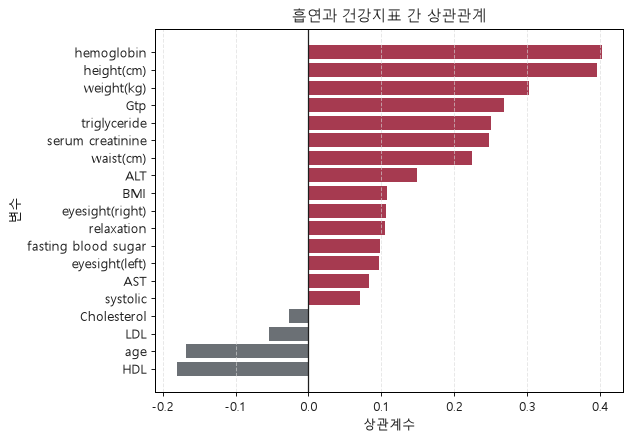

In [ ]:
#상관관계시각화
bar_colors = [COLOR_SMOKER if x > 0 else COLOR_NONSMOKER for x in corr_df['correlation']]

plt.figure(figsize=(7, 5))
plt.barh(corr_df['variable'], corr_df['correlation'], color=bar_colors)
plt.axvline(0, color=COLOR_TEXT, linewidth=1)

plt.title('흡연과 건강지표 간 상관관계', color=COLOR_TEXT)
plt.xlabel('상관계수', color=COLOR_TEXT)
plt.ylabel('변수', color=COLOR_TEXT)
plt.grid(axis='x', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

## 버전 C — 단순 상관계수 산출

In [ ]:
# 흡연 여부와 다른 항목들 간의 상관 계수 구하기
# 수치형 데이터만 선택하여 상관계수 산출
correlations = train_clean.select_dtypes(include=[np.number]).corr()['smoking'].sort_values(ascending=False)

print("--- 'smoking' 항목과의 상관 계수 ---")
display(correlations)

--- 'smoking' 항목과의 상관 계수 ---
smoking                1.000000
hemoglobin             0.402488
height(cm)             0.395455
weight(kg)             0.301805
Gtp                    0.268044
triglyceride           0.251041
serum creatinine       0.247212
waist(cm)              0.224976
ALT                    0.149201
BMI                    0.107735
dental caries          0.107385
eyesight(right)        0.105975
relaxation             0.104368
fasting blood sugar    0.098298
eyesight(left)         0.097287
AST                    0.082912
systolic               0.070547
WHtR                   0.030364
Urine protein          0.014296
hearing(right)        -0.020335
hearing(left)         -0.022810
Cholesterol           -0.027135
LDL                   -0.053937
age                   -0.167949
HDL                   -0.180899
Name: smoking, dtype: float64


## 추가 증빙 — BMI/나이/혈압 상관계수, 전체 히트맵

#### 추가 증빙: BMI/나이/수축기/이완기/HDL의 상관계수

In [ ]:
cols = ['BMI', 'age', 'systolic', 'relaxation', 'BMI', 'smoking']
correlation_matrix = train_clean[cols].corr()

print("--- BMI, 나이, 혈압 간의 상관계수 ---")
display(correlation_matrix)

--- BMI, 나이, 혈압 간의 상관계수 ---
                 BMI       age  systolic  relaxation       BMI   smoking
BMI         1.000000 -0.064601  0.304579    0.284785  1.000000  0.107735
age        -0.064601  1.000000  0.131465    0.048629 -0.064601 -0.167949
systolic    0.304579  0.131465  1.000000    0.759383  0.304579  0.070547
relaxation  0.284785  0.048629  0.759383    1.000000  0.284785  0.104368
BMI         1.000000 -0.064601  0.304579    0.284785  1.000000  0.107735
smoking     0.107735 -0.167949  0.070547    0.104368  0.107735  1.000000


In [ ]:
cols_to_corr = ['Gtp', 'ALT', 'AST', 'waist(cm)', 'age', 'BMI', 'smoking']
correlation_matrix_2 = train_clean[cols_to_corr].corr()

print("--- 간 수치, 허리둘레, 나이, BMI, 흡연 여부 간의 상관계수 ---")
display(correlation_matrix_2)

--- 간 수치, 허리둘레, 나이, BMI, 흡연 여부 간의 상관계수 ---
                Gtp       ALT       AST  ...       age       BMI   smoking
Gtp        1.000000  0.478899  0.427975  ... -0.003054  0.219094  0.268044
ALT        0.478899  1.000000  0.741719  ... -0.109019  0.360426  0.149201
AST        0.427975  0.741719  1.000000  ...  0.036504  0.187075  0.082912
waist(cm)  0.287033  0.379241  0.201262  ... -0.028091  0.821823  0.224976
age       -0.003054 -0.109019  0.036504  ...  1.000000 -0.064601 -0.167949
BMI        0.219094  0.360426  0.187075  ... -0.064601  1.000000  0.107735
smoking    0.268044  0.149201  0.082912  ... -0.167949  0.107735  1.000000

[7 rows x 7 columns]


--- 전체 지표별 상관계수 (상위 10개 행) ---
                      age  height(cm)  weight(kg)  ...   smoking       BMI      WHtR
age              1.000000   -0.481002   -0.325228  ... -0.167949 -0.064601  0.227763
height(cm)      -0.481002    1.000000    0.673887  ...  0.395455  0.141118 -0.125765
weight(kg)      -0.325228    0.673887    1.000000  ...  0.301805  0.821736  0.520380
waist(cm)       -0.028091    0.378606    0.825186  ...  0.224976  0.821823  0.868958
eyesight(left)  -0.330033    0.239346    0.165350  ...  0.097287  0.038831 -0.090323
eyesight(right) -0.328243    0.245244    0.169255  ...  0.105975  0.038919 -0.090144
hearing(left)    0.200329   -0.082092   -0.052458  ... -0.022810 -0.006125  0.067789
hearing(right)   0.205209   -0.080587   -0.053634  ... -0.020335 -0.009671  0.065149
systolic         0.131465    0.082723    0.271184  ...  0.070547  0.304579  0.302375
relaxation       0.048629    0.113511    0.275084  ...  0.104368  0.284785  0.254853

[10 rows x 25 columns]


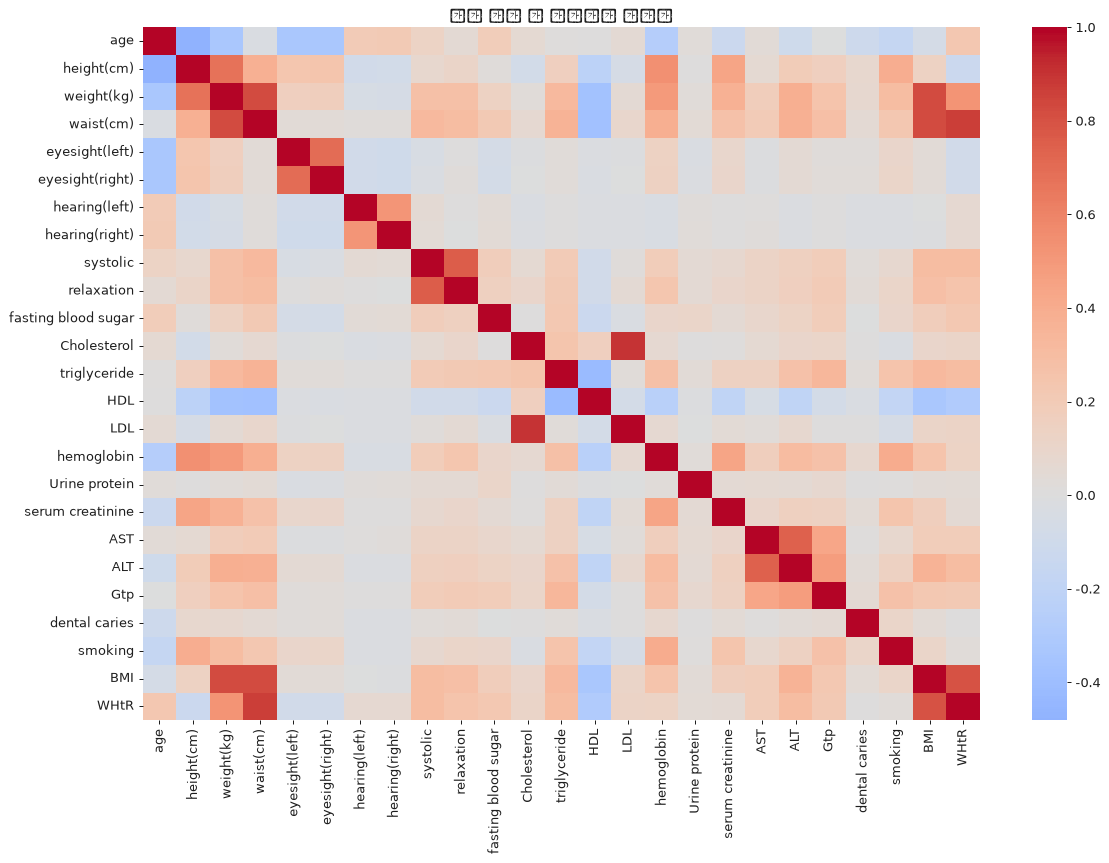

In [ ]:
# 모든 수치형 데이터 간의 상관계수 산출
full_correlation_matrix = train_clean.select_dtypes(include=[np.number]).corr()

print("--- 전체 지표별 상관계수 (상위 10개 행) ---")
display(full_correlation_matrix.head(10))

# 상관계수 히트맵 시각화
plt.figure(figsize=(15, 10))
sns.heatmap(full_correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('전체 지표 간 상관관계 히트맵')
plt.show()

### 나이, BMI, 흡연과 주요 지표 간의 상관관계 분석

--- 나이, BMI, 흡연과 타 지표 간 상관계수 표 ---
              age  height(cm)  weight(kg)  ...   smoking       BMI      WHtR
age      1.000000   -0.481002   -0.325228  ... -0.167949 -0.064601  0.227763
BMI     -0.064601    0.141118    0.821736  ...  0.107735  1.000000  0.802613
smoking -0.167949    0.395455    0.301805  ...  1.000000  0.107735  0.030364

[3 rows x 25 columns]


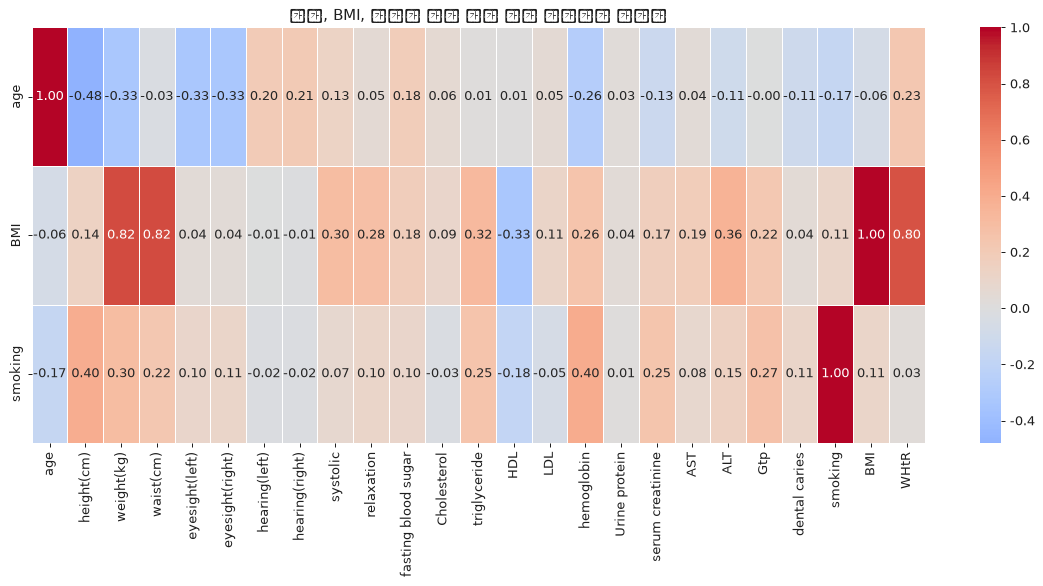

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# train_clean이 정의되어 있는지 확인하고, 필요시 이전 단계의 필터링을 다시 적용합니다.
try:
    # 분석할 대상 컬럼 정의
    target_cols = ['age', 'BMI', 'smoking']
    # 수치형 데이터 전체에 대해 상관계수 계산
    corr_matrix = train_clean.select_dtypes(include=[np.number]).corr()

    # 나이, BMI, 흡연 여부에 대한 상관계수만 추출
    selected_corr = corr_matrix[target_cols].transpose()

    print("--- 나이, BMI, 흡연과 타 지표 간 상관계수 표 ---")
    display(selected_corr)

    # 히트맵 시각화
    plt.figure(figsize=(16, 6))
    sns.heatmap(selected_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('나이, BMI, 흡연과 다른 지표 간의 상관관계 히트맵')
    plt.show()
except NameError:
    print("오류: 'train_clean' 데이터프레임이 메모리에 없습니다. 데이터 로드 및 전처리 셀을 먼저 실행해 주세요.")